
# AIoT Lab — Supervised Machine Learning for AIoT

## Objective
Build a supervised Machine Learning model using synthetic IoT sensor data to simulate predictive intelligence in AIoT systems.

In this lab you will:
- Generate synthetic IoT sensor data
- Perform preprocessing
- Engineer features
- Train a Machine Learning model
- Evaluate predictions
- Simulate real-time AI inference


## Step 1 — Install Required Libraries

In [1]:

!pip install pandas numpy matplotlib scikit-learn


## Step 2 — Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from datetime import datetime, timedelta
import random


## Step 3 — Generate Synthetic IoT Sensor Data

In [5]:

data = []

start_time = datetime.now()

for i in range(200):

    timestamp = start_time + timedelta(seconds=i)

    temperature = round(np.random.normal(30, 5), 2)
    humidity = round(np.random.normal(60, 10), 2)
    pressure = round(np.random.normal(1013, 8), 2)
    vibration = round(np.random.normal(4, 1), 2)
    current = round(np.random.normal(10, 2), 2)

    if random.random() < 0.05:
        temperature = temperature + random.randint(10, 20)

    data.append([
        timestamp,
        temperature,
        humidity,
        pressure,
        vibration,
        current
    ])

df = pd.DataFrame(data, columns=[
    'timestamp',
    'temperature',
    'humidity',
    'pressure',
    'vibration',
    'current'
])

df.head()


,timestamp,temperature,humidity,pressure,vibration,current
0,2026-05-27 12:43:42.334031,27.05,41.83,998.04,5.22,12.58
1,2026-05-27 12:43:43.334031,34.76,51.38,1000.69,3.06,7.75
2,2026-05-27 12:43:44.334031,25.18,50.63,1015.68,3.40,8.65
3,2026-05-27 12:43:45.334031,26.12,41.61,1006.59,2.85,9.72
4,2026-05-27 12:43:46.334031,24.22,63.71,1027.10,4.10,10.69


## Step 4 — Introduce Missing Values

In [7]:

df.loc[2, 'humidity'] = np.nan
df.loc[199, 'pressure'] = np.nan

#df.head()
df.isnull().any(axis=1)
#df.isnull().sum()

0      False
1      False
2       True
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199     True
Length: 200, dtype: bool

## Step 5 — Handle Missing Values

In [9]:
df.isnull().sum()

df['humidity'] = df['humidity'].fillna(df['humidity'].mean())
df['pressure'] = df['pressure'].fillna(df['pressure'].mean())

df.isnull().sum()


timestamp      0
temperature    0
humidity       0
pressure       0
vibration      0
current        0
dtype: int64

## Step 6 — Remove Outliers

In [11]:

q1 = df['temperature'].quantile(0.25)
q3 = df['temperature'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

below_lower_count = (df['temperature'] < lower).sum()
above_upper_count = (df['temperature'] > upper).sum()

print("Before removing ouliers ----------")
print("Below lower boundary:", below_lower_count)
print("Above upper boundary:", above_upper_count)


df = df[(df['temperature'] >= lower) & (df['temperature'] <= upper)]

print("After removing ouliers ----------")
print("Remaining records:", len(df))

below_lower_count = (df['temperature'] < lower).sum()
above_upper_count = (df['temperature'] > upper).sum()

print("Below lower boundary:", below_lower_count)
print("Above upper boundary:", above_upper_count)

Before removing ouliers ----------
Below lower boundary: 0
Above upper boundary: 7
After removing ouliers ----------
Remaining records: 193
Below lower boundary: 0
Above upper boundary: 0


## Step 7 — Normalize Sensor Data

In [13]:

scaler = MinMaxScaler()

columns_to_scale = ['temperature', 'humidity', 'pressure', 'vibration', 'current']

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()


,timestamp,temperature,humidity,pressure,vibration,current
0,2026-05-27 12:43:42.334031,0.329444,0.158049,0.136693,0.719039,0.638169
1,2026-05-27 12:43:43.334031,0.629327,0.332542,0.205168,0.319778,0.221071
2,2026-05-27 12:43:44.334031,0.256709,0.508786,0.592506,0.382625,0.298791
3,2026-05-27 12:43:45.334031,0.293271,0.154029,0.357623,0.280961,0.391192
4,2026-05-27 12:43:46.334031,0.219370,0.557829,0.887597,0.512015,0.474957


## Step 8 — Feature Engineering

In [15]:

df['temp_humidity_ratio'] = df['temperature'] / df['humidity']

df['vibration_current_product'] = df['vibration'] * df['current']

df.head()


,timestamp,temperature,humidity,pressure,vibration,current,temp_humidity_ratio,vibration_current_product
0,2026-05-27 12:43:42.334031,0.329444,0.158049,0.136693,0.719039,0.638169,2.084446,0.458868
1,2026-05-27 12:43:43.334031,0.629327,0.332542,0.205168,0.319778,0.221071,1.892477,0.070694
2,2026-05-27 12:43:44.334031,0.256709,0.508786,0.592506,0.382625,0.298791,0.504553,0.114325
3,2026-05-27 12:43:45.334031,0.293271,0.154029,0.357623,0.280961,0.391192,1.904001,0.109910
4,2026-05-27 12:43:46.334031,0.219370,0.557829,0.887597,0.512015,0.474957,0.393256,0.243185


## Step 9 — Prepare Dataset

In [17]:
#replace all calculations that resulted in infinity with NaN and then drop all drop all rows containing any NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [19]:

X = df[[
    'humidity',
    'pressure',
    'vibration',
    'current',
    'temp_humidity_ratio',
    'vibration_current_product'
]]

y = df['temperature']

X.head()


,humidity,pressure,vibration,current,temp_humidity_ratio,vibration_current_product
0,0.158049,0.136693,0.719039,0.638169,2.084446,0.458868
1,0.332542,0.205168,0.319778,0.221071,1.892477,0.070694
2,0.508786,0.592506,0.382625,0.298791,0.504553,0.114325
3,0.154029,0.357623,0.280961,0.391192,1.904001,0.109910
4,0.557829,0.887597,0.512015,0.474957,0.393256,0.243185


## Step 10 — Split Dataset

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 153
Testing records: 39


## Step 11 — Train Machine Learning Model

In [23]:
print("Infinite values remaining in X_train:", np.isinf(X_train).sum().sum())

Infinite values remaining in X_train: 0


In [25]:
#X.replace([np.inf, -np.inf], np.nan).isna().sum()
#X.replace([np.inf, -np.inf], np.nan, inplace=True)
#X.dropna(inplace=True)
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed")


Model training completed


## Step 12 — Make Predictions

In [27]:

predictions = model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

results.head()


,Actual,Predicted
45,0.465189,0.379619
142,0.491249,0.421553
77,0.501361,0.409140
149,0.563983,0.481746
118,0.469078,0.422163


## Step 13 — Evaluate Model

In [29]:

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", round(mae, 4))
print("R2 Score:", round(r2, 4))


Mean Absolute Error: 0.0933
R2 Score: -0.7296


## Step 14 — Visualization

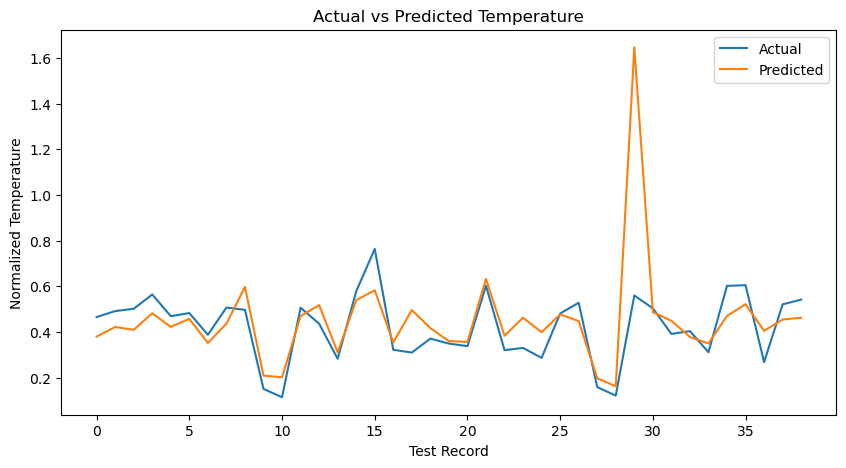

In [31]:

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Record")
plt.ylabel("Normalized Temperature")
plt.legend()

plt.show()


## Step 15 — Simulate Real-Time AIoT Inference

In [33]:

new_sensor_data = pd.DataFrame({
    'humidity': [0.55],
    'pressure': [0.60],
    'vibration': [0.70],
    'current': [0.65],
    'temp_humidity_ratio': [0.55 / 0.60],
    'vibration_current_product': [0.70 * 0.65]
})

prediction = model.predict(new_sensor_data)

print("Predicted Temperature:", round(prediction[0], 4))


Predicted Temperature: 0.4785



# Lab Summary

In this lab you learned how to:

- Generate synthetic IoT sensor data
- Clean and preprocess AIoT datasets
- Perform feature engineering
- Train a supervised ML model
- Evaluate prediction quality
- Simulate real-time AI inference
